In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


#Testando a conexão com o banco de dados e verificando os dados importados

# Conectando com o banco de dados e verificando os dados 
conexaoBanco = sqlite3.connect("../analise_impostos.db")

# Pegando número de registros por setor para verificar se os dados foram importados corretamente
query = "SELECT Setor, COUNT(*) as registros FROM despesas GROUP BY Setor"
dataFrameCheck = pd.read_sql_query(query, conexaoBanco)

print(dataFrameCheck)

                Setor  registros
0            Educação       1469
1  Previdência Social        247
2               Saúde        562
3   Segurança Pública         90
4         Transportes        214


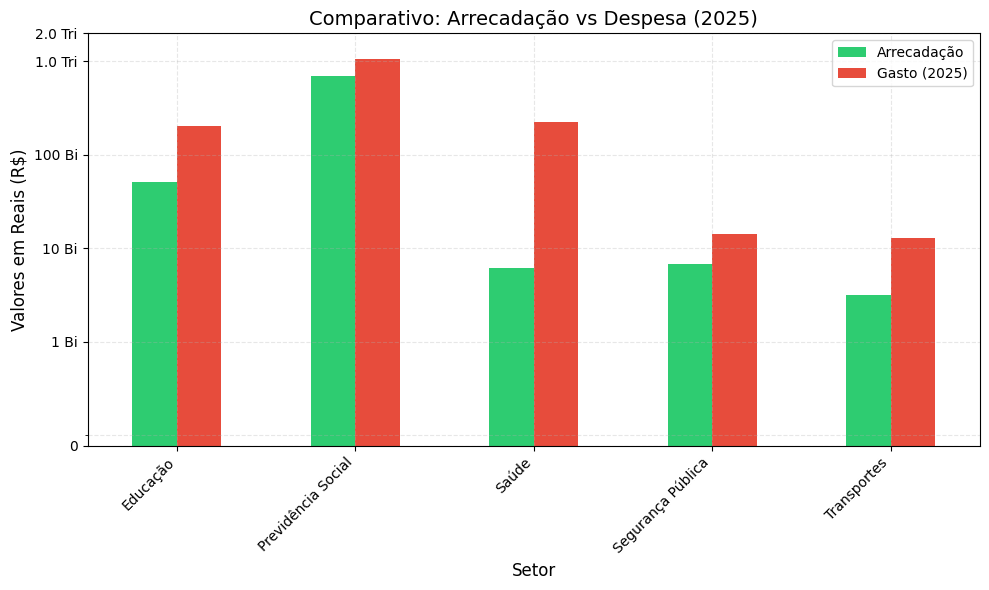

                Setor       totalArrecadado              totalGasto
0            Educação  R$ 51.625.341.265,24   R$ 204.744.841.299,01
1  Previdência Social R$ 704.876.207.719,45 R$ 1.063.415.975.696,21
2               Saúde   R$ 6.223.586.556,73   R$ 223.775.708.486,52
3   Segurança Pública   R$ 6.729.909.757,07    R$ 14.411.629.060,98
4         Transportes   R$ 3.210.381.507,75    R$ 12.829.348.957,86


In [15]:
# 1. Quais foram os Valores de Arrecadações e Despesas Públicas por Setor, 
# Sendo Apenas Despesas de 2025 não Pegando Valores Pagos Atrasados?

import matplotlib.ticker as ticker # Biblioteca para formatar os eixos

#Captando query, aspas triplas para formar um bloco de linhas de códigos SQL
query = """
SELECT 
    r.Setor, 
    SUM(r."Receita Realizada (Valor Arrecadado)") as totalArrecadado,
    (SELECT SUM(d."Valor Pago") FROM despesas d WHERE d.Setor = r.Setor) as totalGasto
FROM receitas r
GROUP BY r.Setor
"""

tabela = pd.read_sql_query(query, conexaoBanco)

# Configuração do gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Plotagem das barras
tabela.plot(x='Setor', y=['totalArrecadado', 'totalGasto'], kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])

# 3. Função para formatar eixo Y em texto amigável
def formatarEixo(valor, pos):
    if valor >= 1e12:
        return f'{valor*1e-12:.1f} Tri'
    elif valor >= 1e9:
        return f'{valor*1e-9:.0f} Bi'
    elif valor >= 1e6:
        return f'{valor*1e-6:.0f} Mi'
    else:
        return f'{valor:,.0f}'

# 4. Ajuste de escala e formatação forçada
# Escala symlog para visibilidade de valores discrepantes
ax.set_yscale('symlog', linthresh=1e9) 

# Aplica a formatação personalizada
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatarEixo))

# Define manualmente os pontos do eixo Y para evitar notação científica automática
ticks = [0, 1e9, 10e9, 100e9, 1e12, 2e12]
ax.set_yticks(ticks)

# 5. Ajustes estéticos finais
plt.title("Comparativo: Arrecadação vs Despesa (2025)", fontsize=14)
plt.ylabel("Valores em Reais (R$)", fontsize=12)
plt.xlabel("Setor", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(["Arrecadação", "Gasto (2025)"], loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

plt.show()

# Exibição da tabela formatada no padrão brasileiro
pd.options.display.float_format = lambda x: 'R$ {:,.2f}'.format(x).replace(',', 'X').replace('.', ',').replace('X', '.')
print(tabela)

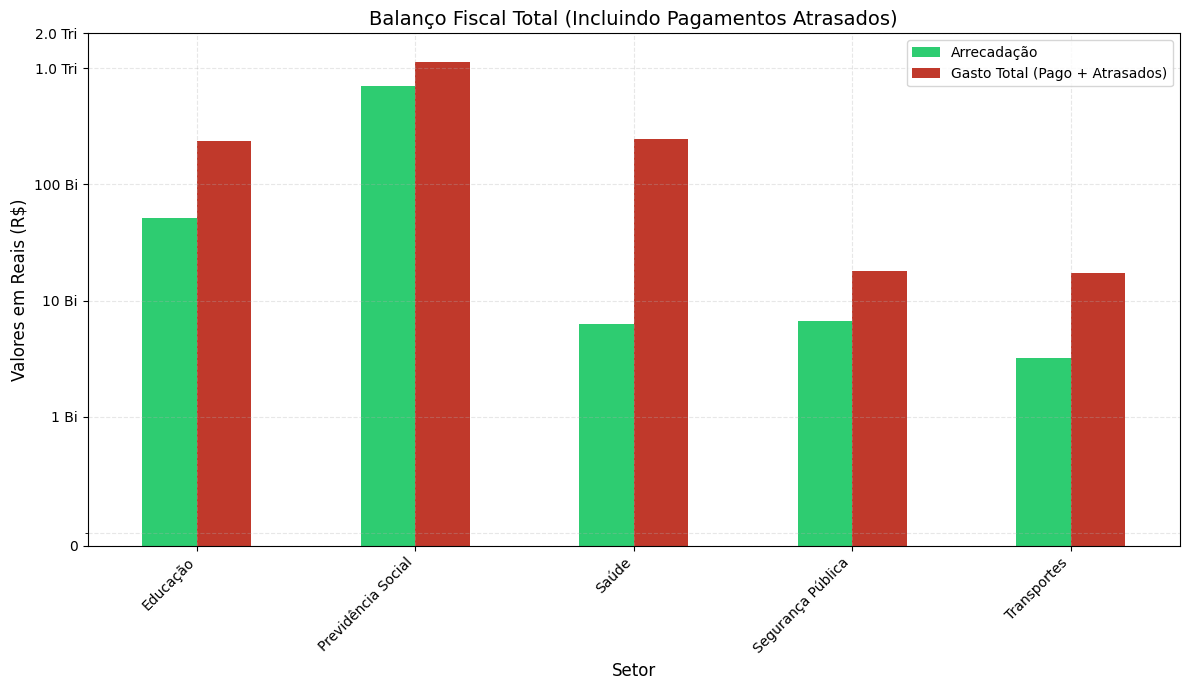

                Setor       totalArrecadado         totalGastoTotal
0            Educação  R$ 51.625.341.265,24   R$ 234.416.405.160,31
1  Previdência Social R$ 704.876.207.719,45 R$ 1.126.246.910.537,60
2               Saúde   R$ 6.223.586.556,73   R$ 246.335.524.960,62
3   Segurança Pública   R$ 6.729.909.757,07    R$ 17.850.502.831,04
4         Transportes   R$ 3.210.381.507,75    R$ 17.170.457.429,19


In [19]:
# 2. Qual a comparação despesas versus receitas, captando valores pagos em 2025 sendo de despesas anteriores a este período?

# Nova Query (Soma o Pago + Restos a Pagar), captando coluna valor restos a pagar pagos.
queryGastoTotal = """
SELECT 
    r.Setor, 
    SUM(r."Receita Realizada (Valor Arrecadado)") as totalArrecadado,
    (SELECT SUM(d."Valor Pago" + d."Valor Restos a Pagar Pagos") 
     FROM despesas d 
     WHERE d.Setor = r.Setor) as totalGastoTotal
FROM receitas r
GROUP BY r.Setor
"""
tabelaGastoTotal = pd.read_sql_query(queryGastoTotal, conexaoBanco)

# Criar o novo gráfico
fig, ax = plt.subplots(figsize=(12, 7))
tabelaGastoTotal.plot(x='Setor', y=['totalArrecadado', 'totalGastoTotal'], kind='bar', ax=ax, color=['#2ecc71', '#c0392b'])

# Aplicar a escala symlog e a formatação textual forçada
# Escala symlog para visibilidade de valores discrepantes
ax.set_yscale('symlog', linthresh=1e9) 

# Forçar o uso da função de formatação personalizada (formatarEixo deve estar definida em célula anterior)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatarEixo))

# Definir manualmente os locais dos ticks para evitar que o matplotlib use notação científica
ticks = [0, 1e9, 10e9, 100e9, 1e12, 2e12]
ax.set_yticks(ticks)

# 4. Ajustes estéticos finais
plt.title("Balanço Fiscal Total (Incluindo Pagamentos Atrasados)", fontsize=14)
plt.ylabel("Valores em Reais (R$)", fontsize=12)
plt.xlabel("Setor", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(["Arrecadação", "Gasto Total (Pago + Atrasados)"], loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

plt.show()

# Exibição da tabela formatada no padrão brasileiro
pd.options.display.float_format = lambda x: 'R$ {:,.2f}'.format(x).replace(',', 'X').replace('.', ',').replace('X', '.')
print(tabelaGastoTotal)


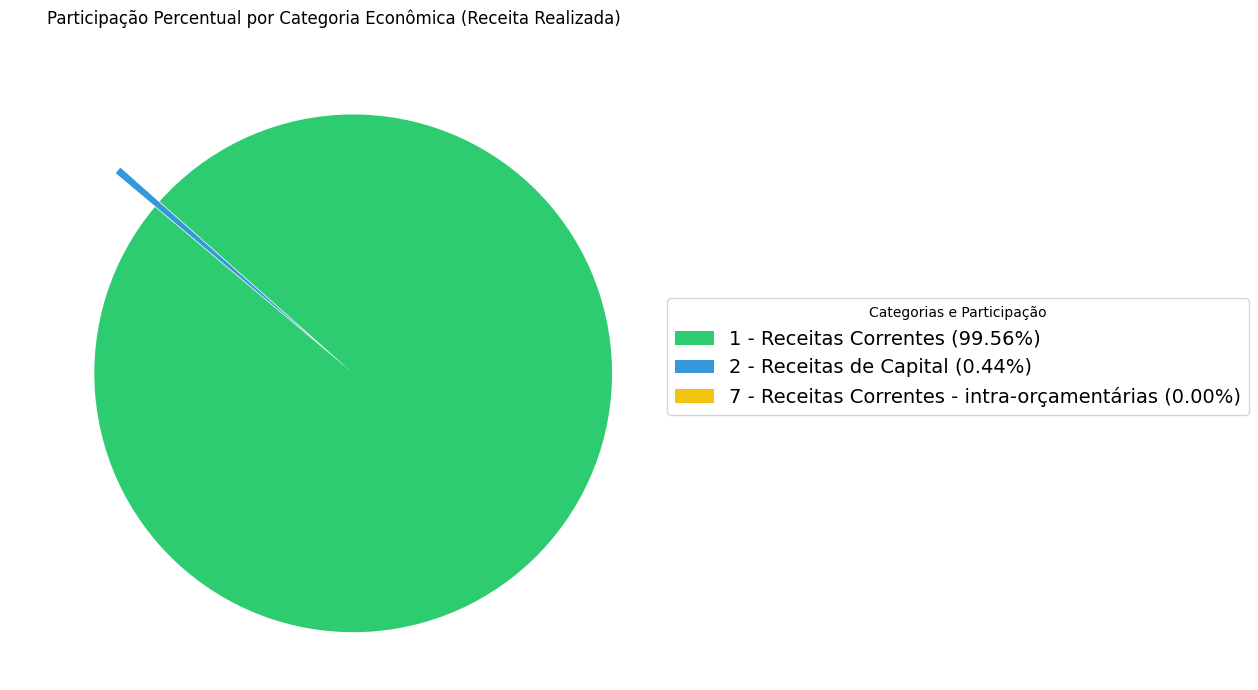

                                      Categoria       totalArrecadado  \
0                        1 - Receitas Correntes R$ 769.240.599.453,58   
1                       2 - Receitas de Capital   R$ 3.416.775.638,79   
2  7 - Receitas Correntes - intra-orçamentárias       R$ 8.051.713,87   

   porcentagem  
0     R$ 99,56  
1      R$ 0,44  
2      R$ 0,00  


In [27]:
# 3. Qual é a participação percentual de cada categoria econômica (Correntes, Capital, Intra-orçamentárias) 
# no total da receita arrecadada pelo governo?

# 1. Query e Cálculo de Porcentagem Manual
queryCategoria = """
SELECT Categoria, SUM("Receita Realizada (Valor Arrecadado)") as totalArrecadado
FROM receitas
GROUP BY Categoria
"""
tabelaCategoria = pd.read_sql_query(queryCategoria, conexaoBanco)

# Cálculo da porcentagem para colocar na legenda
totalGeral = tabelaCategoria['totalArrecadado'].sum()
tabelaCategoria['porcentagem'] = (tabelaCategoria['totalArrecadado'] / totalGeral) * 100

# Criação do rótulo personalizado para a legenda: "Nome da Categoria (0.00%)"
legendas_personalizadas = [
    f"{cat} ({perc:.2f}%)" 
    for cat, perc in zip(tabelaCategoria['Categoria'], tabelaCategoria['porcentagem'])
]

# 2. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Criando a pizza (Note que removi o 'autopct' para limpar o gráfico)
wedges, texts = ax.pie(
    tabelaCategoria['totalArrecadado'], 
    startangle=140, # Ângulo do gráfico
    colors=['#2ecc71', '#3498db', '#f1c40f'], # Cores usadas
    explode=(0.1, 0.1, 0.1) # Mantém o destaque das fatias
)

# 3. Adicionar a Legenda com as porcentagens calculadas
ax.legend(wedges, legendas_personalizadas,
          title="Categorias e Participação", # título da legenda
          loc="center left", # Ponto da caixa da legenda
          bbox_to_anchor=(1, 0, 0.5, 1), # Posição da legenda, tornando fora do gráfico pizza
          fontsize=14) # Tamanho fonte do texto

# 4. Ajustes finais
plt.title("Participação Percentual por Categoria Econômica (Receita Realizada)")
plt.tight_layout()
plt.show()

print(tabelaCategoria)


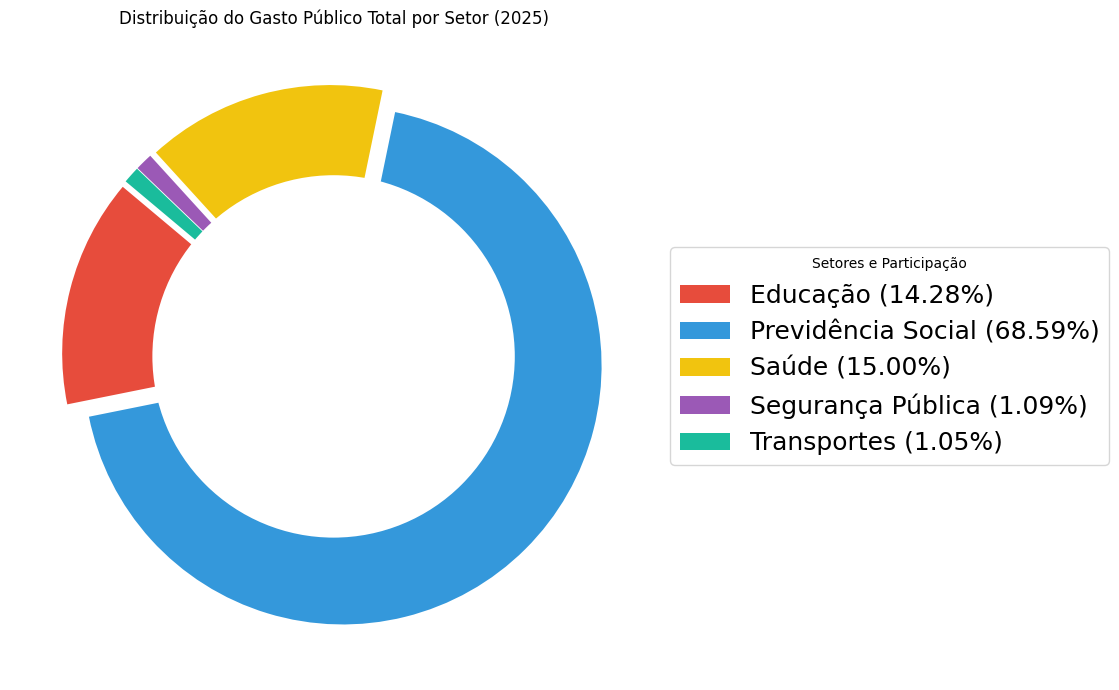

                Setor         totalGastoTotal  porcentagem
0            Educação   R$ 234.416.405.160,31     R$ 14,28
1  Previdência Social R$ 1.126.246.910.537,60     R$ 68,59
2               Saúde   R$ 246.335.524.960,62     R$ 15,00
3   Segurança Pública    R$ 17.850.502.831,04      R$ 1,09
4         Transportes    R$ 17.170.457.429,19      R$ 1,05


In [31]:
# 4. Como se divide o bolo orçamentário entre os grandes setores? (Gráfico de Rosca)

# 1. Query para buscar os gastos totais por setor 
queryGastoSetor = """
SELECT 
    Setor, 
    SUM("Valor Pago" + "Valor Restos a Pagar Pagos") as totalGastoTotal
FROM despesas
GROUP BY Setor
"""
tabelaGastoSetor = pd.read_sql_query(queryGastoSetor, conexaoBanco)

# 2. Cálculo de porcentagem para a legenda (Para evitar o erro de números embolados)
totalGeralGasto = tabelaGastoSetor['totalGastoTotal'].sum()
tabelaGastoSetor['porcentagem'] = (tabelaGastoSetor['totalGastoTotal'] / totalGeralGasto) * 100

# Criação dos rótulos da legenda seguindo o padrão: "Setor (0.00%)"
legendasSetores = [
    f"{setor} ({perc:.2f}%)" 
    for setor, perc in zip(tabelaGastoSetor['Setor'], tabelaGastoSetor['porcentagem'])
]

# 3. Criação do gráfico 
fig, ax = plt.subplots(figsize=(12, 7))

# Criando a pizza (wedges são as fatias)
wedges, texts = ax.pie(
    tabelaGastoSetor['totalGastoTotal'], 
    startangle=140, 
    colors=['#e74c3c', '#3498db', '#f1c40f', '#9b59b6', '#1abc9c'], # Cores consistentes
    explode=[0.05] * len(tabelaGastoSetor) # Afasta as fatias levemente (padrão 0.05)
)

# 4. Transformando em Rosca (Adicionando o círculo branco no centro)
circuloCentral = plt.Circle((0,0), 0.70, fc='white') # Cria o círculo central
fig.gca().add_artist(circuloCentral)               # Adiciona o círculo ao gráfico existente

# 5. Aplicar a Legenda lateral 
ax.legend(wedges, legendasSetores,
          title="Setores e Participação",
          loc="center left",           # Referência: lado esquerdo central da legenda
          bbox_to_anchor=(1, 0, 0.5, 1), # Posição: fora do gráfico à direita
          fontsize=18)                 # Tamanho da fonte

# 6. Ajustes finais 
plt.title("Distribuição do Gasto Público Total por Setor (2025)")
plt.tight_layout()
plt.show()

# Exibe a tabela para conferência
print(tabelaGastoSetor)


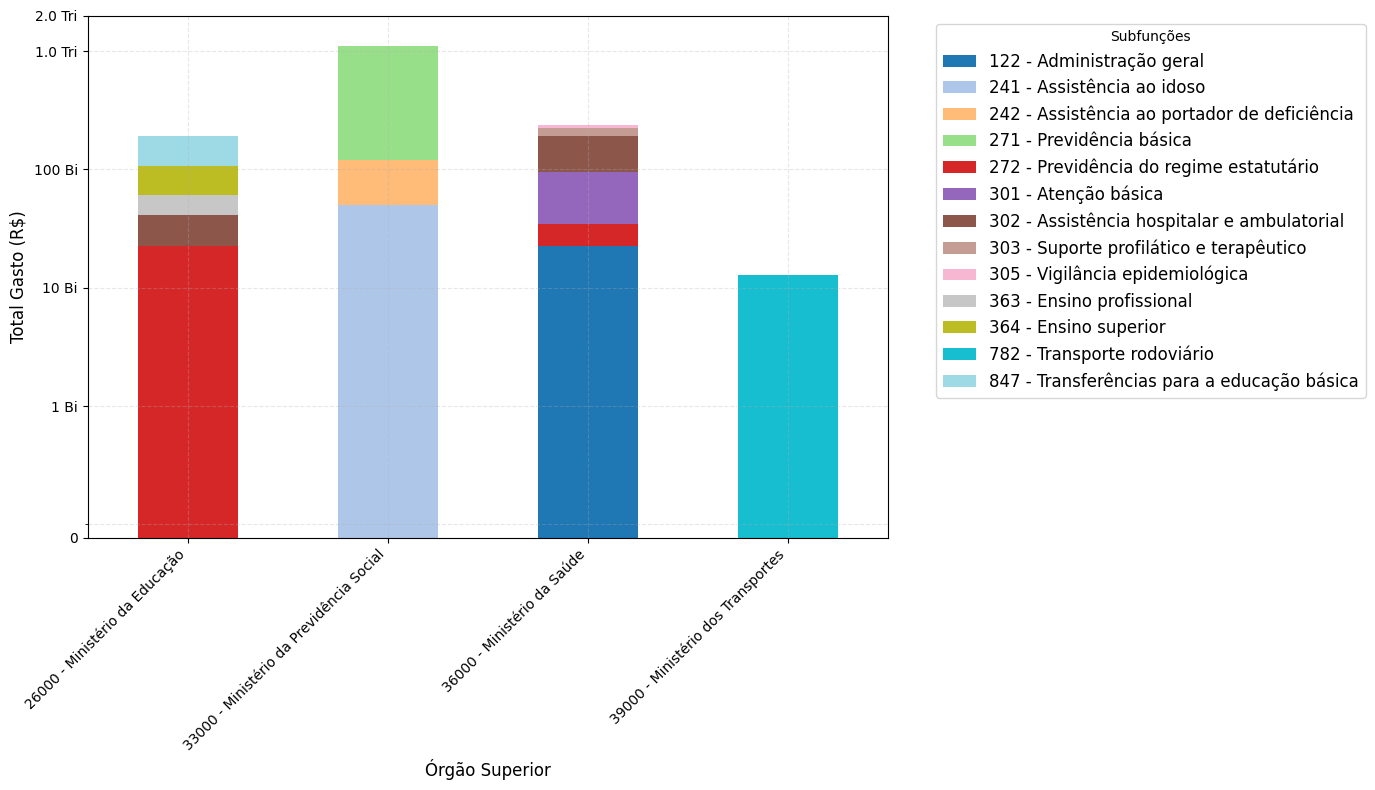

                                       Orgao  \
0   33000 - Ministério da Previdência Social   
1                36000 - Ministério da Saúde   
2             26000 - Ministério da Educação   
3   33000 - Ministério da Previdência Social   
4                36000 - Ministério da Saúde   
5   33000 - Ministério da Previdência Social   
6             26000 - Ministério da Educação   
7                36000 - Ministério da Saúde   
8                36000 - Ministério da Saúde   
9             26000 - Ministério da Educação   
10            26000 - Ministério da Educação   
11            26000 - Ministério da Educação   
12               36000 - Ministério da Saúde   
13        39000 - Ministério dos Transportes   
14               36000 - Ministério da Saúde   

                                       Subfuncao            totalGasto  
0                       271 - Previdência básica R$ 986.989.088.438,24  
1    302 - Assistência hospitalar e ambulatorial  R$ 97.608.608.816,69  
2    847 - T

In [35]:
# 5. Dentro do orçamento geral, quais são as 15 subfunções (ex: Atenção Básica, Previdência, etc.) 
# que mais concentram recursos públicos? 


# 1. Consulta SQL para identificar o gasto total por Órgão e Subfunção
queryGastoOrgaoSub = """
SELECT 
    "Órgão Superior" as Orgao, 
    Subfunção as Subfuncao,
    SUM("Valor Pago" + "Valor Restos a Pagar Pagos") as totalGasto
FROM despesas
GROUP BY Orgao, Subfuncao
ORDER BY totalGasto DESC
LIMIT 15
"""
tabelaGastoOrgaoSub = pd.read_sql_query(queryGastoOrgaoSub, conexaoBanco)

# Pivotagem dos dados para criar o formato de barras empilhadas
dfPivot = tabelaGastoOrgaoSub.pivot(index='Orgao', columns='Subfuncao', values='totalGasto')

# 2. Inicialização do gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(14, 8))
dfPivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

# 3. Aplicar escala symlog e formatação textual personalizada
# O linthresh ajuda a dar "zoom" nos valores menores (Bilhões) sem esconder os maiores (Trilhões)
ax.set_yscale('symlog', linthresh=1e9) 

# Forçar o uso da função de formatação personalizada (definida anteriormente)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatarEixo))

# Definir manualmente os locais dos ticks para evitar notação científica automática
ticks = [0, 1e9, 10e9, 100e9, 1e12, 2e12]
ax.set_yticks(ticks)

# 4. Configurações de layout e legendas
plt.ylabel("Total Gasto (R$)", fontsize=12)
plt.xlabel("Órgão Superior", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Subfunções", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

plt.show()

# Exibição dos dados consolidados no padrão brasileiro
pd.options.display.float_format = lambda x: 'R$ {:,.2f}'.format(x).replace(',', 'X').replace('.', ',').replace('X', '.')
print(tabelaGastoOrgaoSub)


<Figure size 640x480 with 0 Axes>

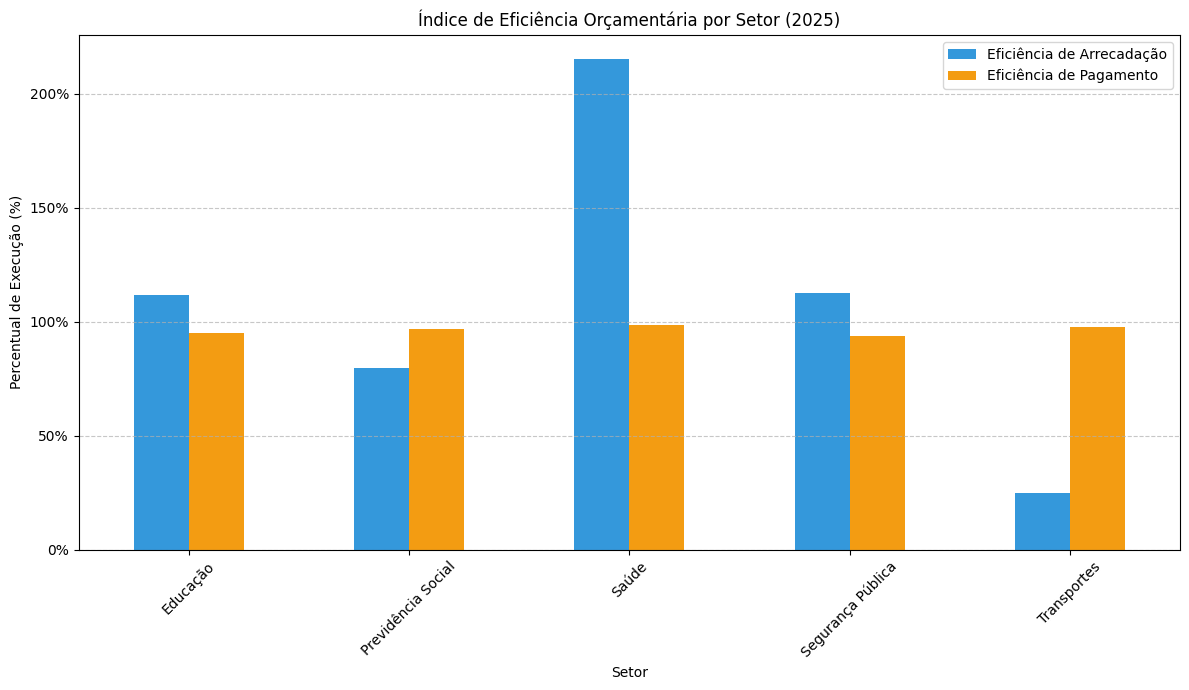

                Setor  percArrecadacao  percPagamento
0            Educação       111.789376      94.855407
1  Previdência Social        79.526716      96.807615
2               Saúde       215.019027      98.617902
3   Segurança Pública       112.416845      93.517366
4         Transportes        24.733780      97.822125


In [23]:
# 1. Resetar a configuração global do Pandas para remover o "R$" automático
import pandas as pd
pd.reset_option('display.float_format')

# 2. Consulta SQL para calcular os índices de eficiência
queryEficiencia = """
SELECT 
    r.Setor,
    (SUM(r."Receita Realizada (Valor Arrecadado)") / SUM(r."Orçamento Atualizado (Valor Previsto)")) * 100 as percArrecadacao,
    (SELECT (SUM(d."Valor Pago") / SUM(d."Valor Liquidado")) * 100 
     FROM despesas d 
     WHERE d.Setor = r.Setor) as percPagamento
FROM receitas r
GROUP BY r.Setor
"""
tabelaEficiencia = pd.read_sql_query(queryEficiencia, conexaoBanco)

# 3. Inicialização do gráfico (Limpando qualquer configuração anterior)
plt.clf() # Limpa a figura atual
fig, ax = plt.subplots(figsize=(12, 7))

# 4. Plotagem das barras
tabelaEficiencia.plot(x='Setor', 
                      y=['percArrecadacao', 'percPagamento'], 
                      kind='bar', 
                      ax=ax, 
                      color=['#3498db', '#f39c12'])

# 5. Forçar o eixo Y a mostrar apenas números e o símbolo de %
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}%'))

# 6. Configurações de títulos e rótulos
plt.title("Índice de Eficiência Orçamentária por Setor (2025)")
plt.ylabel("Percentual de Execução (%)")
plt.xlabel("Setor")
plt.xticks(rotation=45)
plt.legend(["Eficiência de Arrecadação", "Eficiência de Pagamento"])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Exibição dos dados (Agora sem o R$ no console)
print(tabelaEficiencia)
